Varactor D=100um and w=60um bonded at the DUT position to test the bridge, R_ref = 27 kOhm

In [1]:
from impedance_bridge_analysis.load_data import LoadData, get_parameter_snapshot_value
from impedance_bridge_analysis.plotting import Plotter

from impedance_bridge_analysis.calculation import bridge_calculation


import numpy as np
import matplotlib.pyplot as plt

%matplotlib ipympl

In [2]:
R_ref = 27e3

plotr = Plotter(theme="presentation")
calc = bridge_calculation(R_ref)

base_path = r"C:\Users\s.schreibing\Documents\qimchi_data\impedance_bridge\STO varactor, batch 1\D=100um, w=60um"

plot the 2d sweep of reference amplitude voltage and phase difference

In [3]:
experiment_name = r"\lockin_amplitude_ref and phase sweep - V_dut = 7.00 V"
id = 2

loader = LoadData(data_path = base_path + experiment_name)
data = loader.load_zarr(run_id=id)

V_dut = get_parameter_snapshot_value(data, "V_dut")

min v_out_r: 79.87 uV


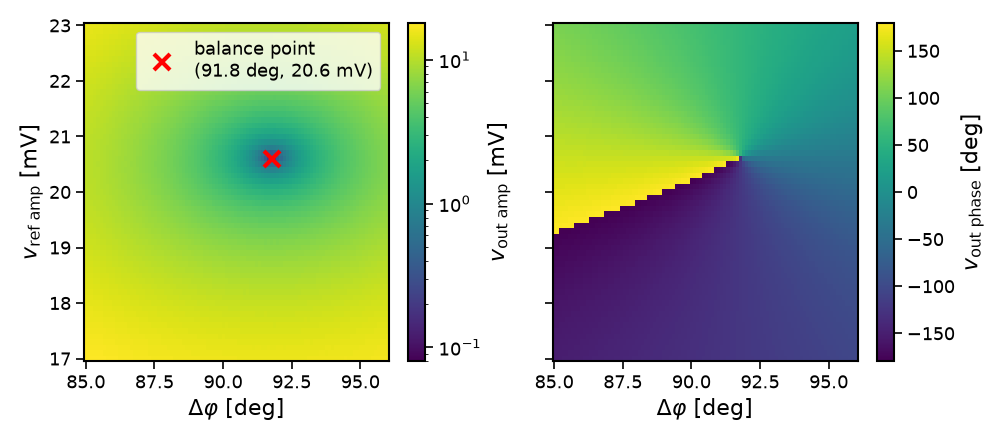

In [4]:
plotr.lockin_ref_phase_sweep(data, size_factor=1.6, balance_point=True, log_scale=True, save_path=rf"\plots\lockin_ref_phase_sweep_{V_dut:.2f}V_dut_bias_{id}_log.png")

In [5]:
# Capacitor modeled as parallel R and C
Z_dut = calc.calculate_impedance(data)

print(f"Impedance: {Z_dut:.2f} Ohm")

Impedance: 2439.64-78601.73j Ohm


2d sweep of lockin amp ref and dut bias

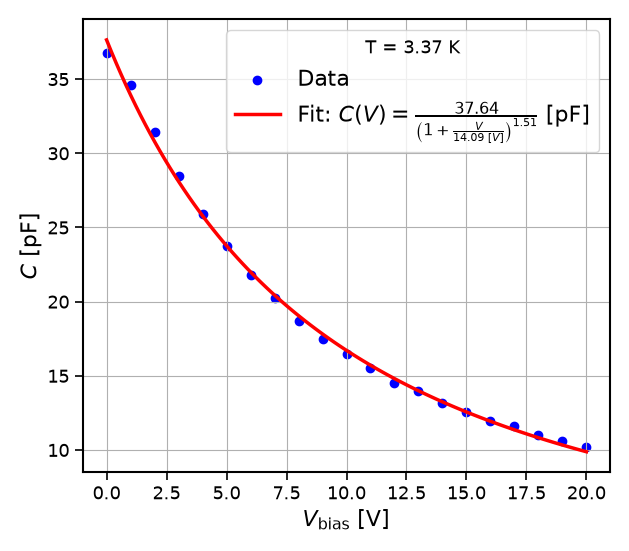

Temperature: 3.37 K


In [3]:
experiment_name = r"\lockin_amplitude_ref and DUT bias sweep"
id = 2

loader = LoadData(data_path = base_path + experiment_name)
data = loader.load_zarr(run_id=id)

plotr.lockin_ref_dut_bias_sweep(data, size_factor=2, fit=True, save_path=rf"\plots\lockin_ref_amplitude_dut_bias_sweep_{id}.png")

T = get_parameter_snapshot_value(data, "T4k")
print(f"Temperature: {T:.2f} K")

C:\Users\s.schreibing\Documents\coding-git\impedance_bridge_analysis\src\impedance_bridge_analysis\plotting.py:269: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


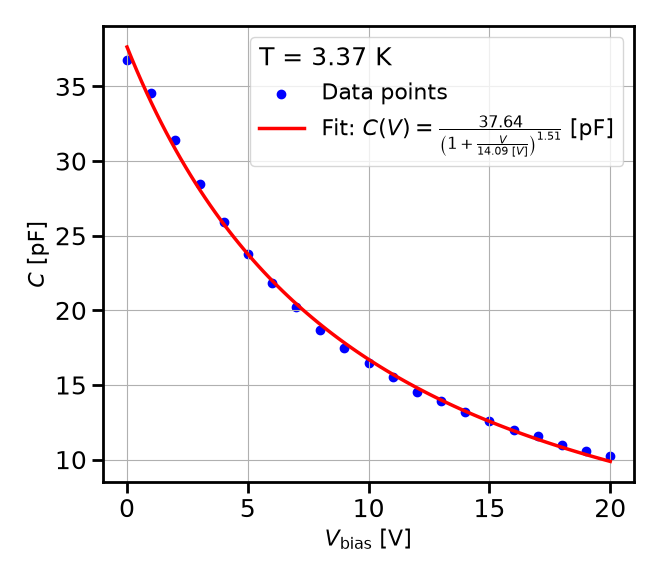

Temperature: 3.37 K


In [3]:
#same plot for sq7 poster
plotr_poster = Plotter(theme="poster")

experiment_name = r"\lockin_amplitude_ref and DUT bias sweep"
id = 2

loader = LoadData(data_path = base_path + experiment_name)
data = loader.load_zarr(run_id=id)

plotr_poster.lockin_ref_dut_bias_sweep(data, size_factor=2.1, fit=True, save_path=rf"\plots\lockin_ref_amplitude_dut_bias_sweep_{id}_poster.pdf")

T = get_parameter_snapshot_value(data, "T4k")
print(f"Temperature: {T:.2f} K")

gamma from the fit shows if the varactors are hyper abrupt: here ~1.5 so yes

do a phase amp ref sweep for each bias voltage

C:\Users\s.schreibing\AppData\Local\Temp\ipykernel_47952\2016623316.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


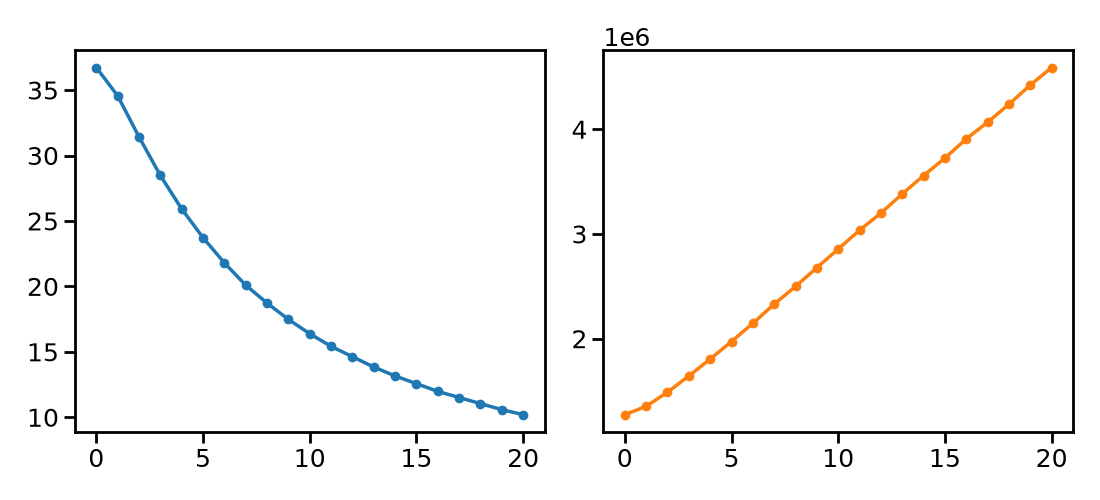

In [8]:

id_list = [2,1,1,1,1,1,1,3,1,1,1,1,1,1,1,1,1,1,1,1,1]

Z = []
V = []

for n, V_dut in enumerate(["0.00", "1.00", "2.00", "3.00", "4.00", "5.00", "6.00", "7.00", "8.00", "9.00", "10.00", "11.00", "12.00", "13.00", "14.00", "15.00", "16.00", "17.00", "18.00", "19.00", "20.00"]):
    experiment_name = rf"\lockin_amplitude_ref and phase sweep - V_dut = {V_dut} V"
    id = id_list[n]

    loader = LoadData(data_path = base_path + experiment_name)
    data = loader.load_zarr(run_id=id)

    Z_dut = calc.calculate_impedance(data)

    Z.append(Z_dut)
    V.append(float(V_dut))


f = get_parameter_snapshot_value(data, "lockin_frequency")
R, C = calc.calculate_RC_from_dut_Impedance(Z, f)

fig, ax = plt.subplots(1, 2, figsize=(11,5))

ax[0].plot(V, C*1e12, marker="o", markersize=6, color="C0", label="Measured Impedance")
ax[1].plot(V, R, marker="o", markersize=6, color="C1", label="Measured Impedance")

plt.tight_layout()
plt.show()


C:\Users\s.schreibing\Documents\coding-git\impedance_bridge_analysis\src\impedance_bridge_analysis\plotting.py:324: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


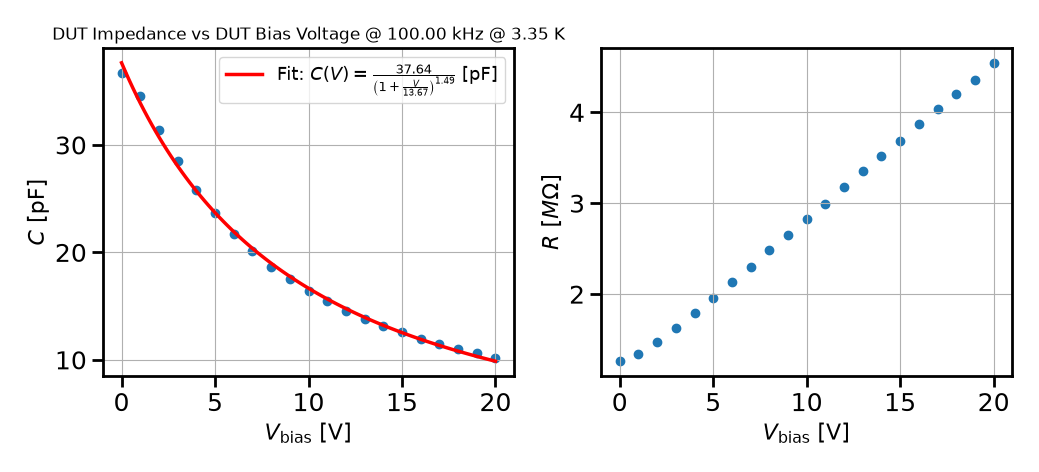

In [9]:
id_list = np.linspace(1,21,21)
experiment_name = r"\amp ref phase bias sweep"

loader = LoadData(data_path = base_path + experiment_name)
data_list = [loader.load_zarr(run_id=int(id)) for id in id_list]

plotr.lockin_ref_phase_dut_bias_3d_sweep(data_list, size_factor=2.4, fit=True, save_path=rf"\plots\lockin_ref_phase_dut_bias_3d_sweep.png")